<a href="https://colab.research.google.com/github/Fachreza28/pba-task-1a-individual/blob/main/Week%203/WEEK3_BoW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#BoW bag of Words


# Step 1: Tokenize the data, remove stop words and perform stemming or lemmatization.

 Install & Import

In [1]:
!pip install sastrawi --quiet

import nltk
nltk.download('stopwords', quiet=True)

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.6 MB/s eta 0:00:00


Load Data

In [2]:
#### Load CSV dari local / upload
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('df_mybcarev_after_stopwords_sentiment_rating2.csv')
print("Shape asli:", df.shape)
df.head()

Saving df_mybcarev_after_stopwords_sentiment_rating2.csv to df_mybcarev_after_stopwords_sentiment_rating2.csv
Shape asli: (512156, 7)


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating,spelled_correction,tweet_without_stopwords
0,ok,5,0.5,0.5,Positive,ok,ok
1,susa amat buat qris di cek internet bagus dico...,1,0.0,0.0,Negative,susa amat buat qris di cek internet bagus dico...,susa qris cek internet bagus dicoba buka apk b...
2,ter indah tiasa 2 nya,5,0.0,0.0,Positive,ter indah tiasa 2 nya,ter indah tiasa 2
3,dengan bca mobile transaksi lebih mudah ga pak...,5,0.0,0.0,Positive,dengan bca mobile transaksi lebih mudah tidak ...,bca mobile transaksi mudah pake ngantridulu bc...
4,bca mobile memang luar biasa ok🙏🙏👍🤣🤣,5,0.0,0.0,Positive,bca mobile memang luar biasa ok🙏🙏👍🤣🤣,bca mobile ok🙏🙏👍🤣🤣


Cek Data

In [3]:
print("=== INFO DATASET ===")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"\nKolom: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTipe data:\n{df.dtypes}")

=== INFO DATASET ===
Jumlah baris  : 512,156
Jumlah kolom  : 7

Kolom: ['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'sentiment_rating', 'spelled_correction', 'tweet_without_stopwords']

Missing values:
content                      157
score                          0
sentiment_polarity             0
sentiment_subjective           0
sentiment_rating               0
spelled_correction           157
tweet_without_stopwords    12016
dtype: int64

Tipe data:
content                     object
score                        int64
sentiment_polarity         float64
sentiment_subjective       float64
sentiment_rating            object
spelled_correction          object
tweet_without_stopwords     object
dtype: object


EDA: Distribusi Sentiment & Score

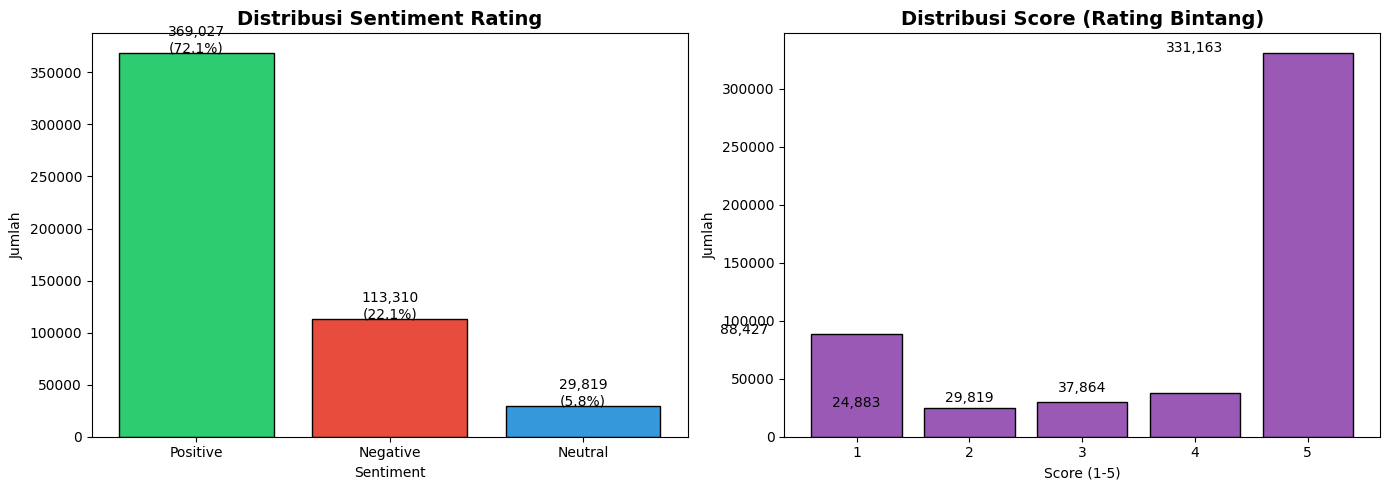


Distribusi Sentiment Rating:
sentiment_rating
Positive    369027
Negative    113310
Neutral      29819
Name: count, dtype: int64

Proporsi:
sentiment_rating
Positive    72.05
Negative    22.12
Neutral      5.82
Name: count, dtype: float64%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi sentiment_rating
sentiment_counts = df['sentiment_rating'].value_counts()
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db'}
bar_colors = [colors.get(s, '#95a5a6') for s in sentiment_counts.index]

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, edgecolor='black')
axes[0].set_title('Distribusi Sentiment Rating', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Jumlah')
for i, (label, val) in enumerate(zip(sentiment_counts.index, sentiment_counts.values)):
    axes[0].text(i, val + 500, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Plot 2: Distribusi score (bintang)
score_counts = df['score'].value_counts().sort_index()
axes[1].bar(score_counts.index, score_counts.values, color='#9b59b6', edgecolor='black')
axes[1].set_title('Distribusi Score (Rating Bintang)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score (1-5)')
axes[1].set_ylabel('Jumlah')
for i, (score, val) in enumerate(zip(score_counts.index, score_counts.values)):
    axes[1].text(score - 1, val + 500, f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDistribusi Sentiment Rating:")
print(sentiment_counts)
print(f"\nProporsi:\n{(sentiment_counts / len(df) * 100).round(2)}%")

EDA: Panjang Teks

/tmp/ipykernel_14202/25773173.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=sentiment_order, patch_artist=True,


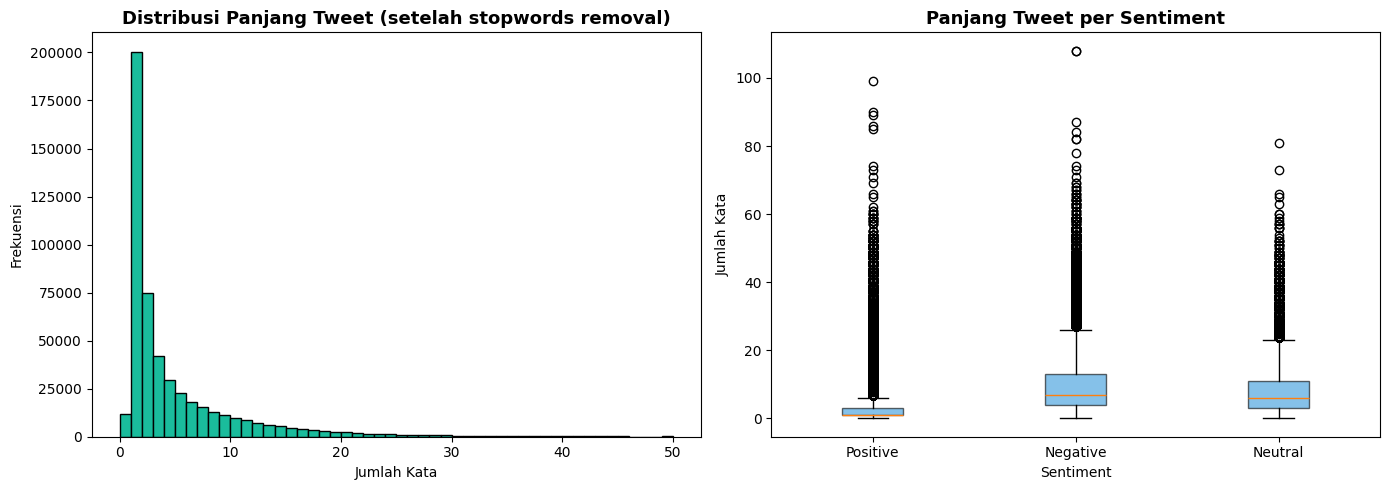


Statistik panjang tweet:
                     count  mean   std  min  25%  50%   75%    max
sentiment_rating                                                  
Negative          113310.0  9.66  8.20  0.0  4.0  7.0  13.0  108.0
Neutral            29819.0  8.00  7.33  0.0  3.0  6.0  11.0   81.0
Positive          369027.0  2.80  3.96  0.0  1.0  1.0   3.0   99.0


In [5]:
df['panjang_tweet'] = df['tweet_without_stopwords'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram panjang teks
axes[0].hist(df['panjang_tweet'].clip(upper=50), bins=50, color='#1abc9c', edgecolor='black')
axes[0].set_title('Distribusi Panjang Tweet (setelah stopwords removal)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')

# Boxplot panjang teks per sentiment
sentiment_order = df['sentiment_rating'].value_counts().index.tolist()
data_box = [df[df['sentiment_rating'] == s]['panjang_tweet'].values for s in sentiment_order]
bp = axes[1].boxplot(data_box, labels=sentiment_order, patch_artist=True,
                     boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1].set_title('Panjang Tweet per Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Jumlah Kata')

plt.tight_layout()
plt.savefig('eda_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nStatistik panjang tweet:")
print(df.groupby('sentiment_rating')['panjang_tweet'].describe().round(2))

EDA: Top 20 Kata per Sentiment

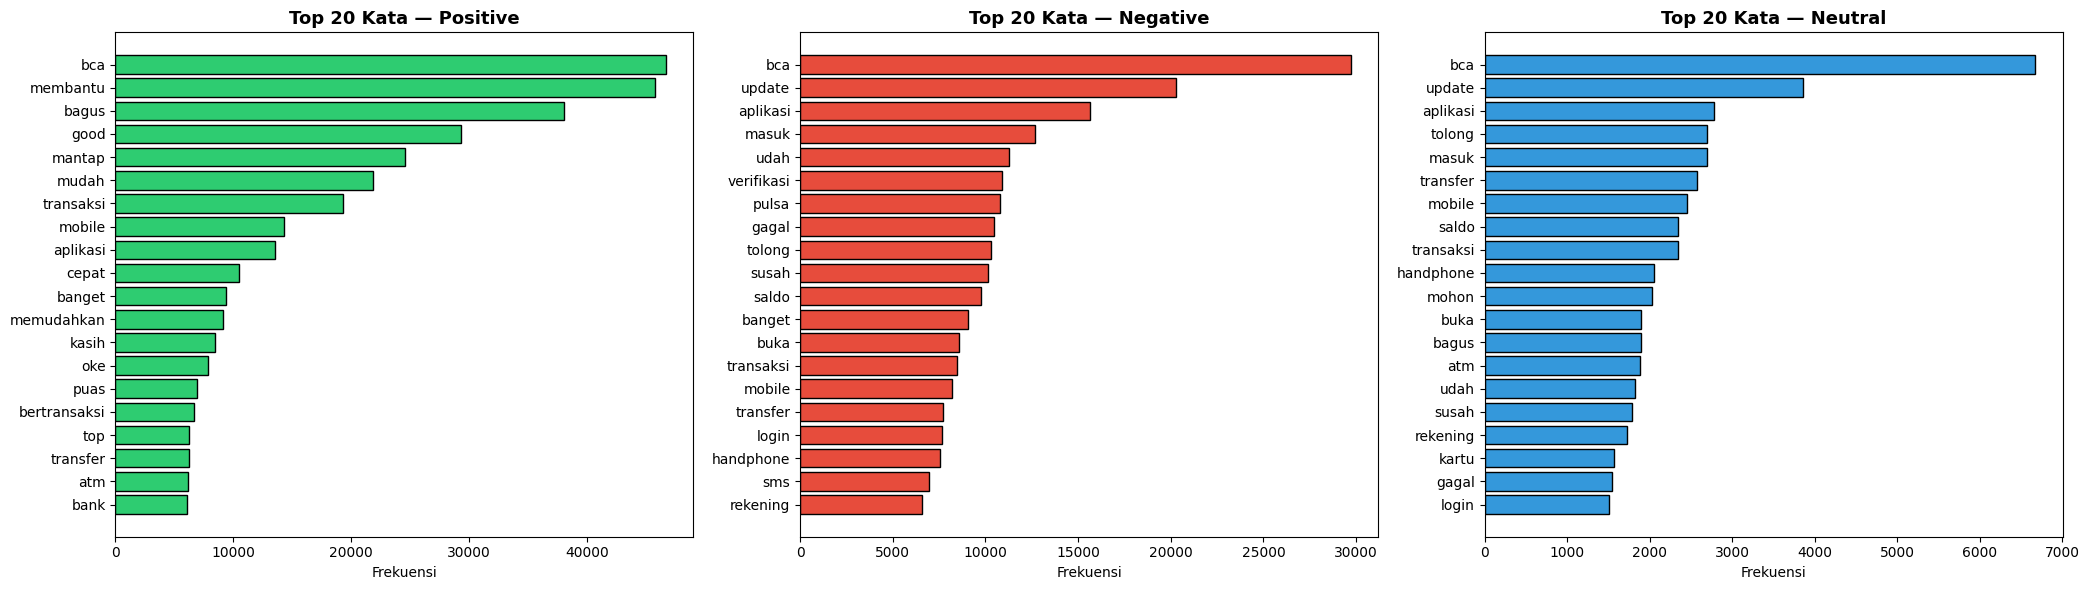

In [6]:
def get_top_words(df_subset, col='tweet_without_stopwords', n=20):
    all_words = []
    for text in df_subset[col].dropna():
        words = re.sub(r'[^a-zA-Z\s]', ' ', str(text)).lower().split()
        all_words.extend([w for w in words if len(w) > 2])
    return Counter(all_words).most_common(n)

sentiments = df['sentiment_rating'].unique()
fig, axes = plt.subplots(1, len(sentiments), figsize=(7 * len(sentiments), 6))
if len(sentiments) == 1:
    axes = [axes]

palette = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
for ax, sentiment, color in zip(axes, sentiments, palette):
    top_words = get_top_words(df[df['sentiment_rating'] == sentiment])
    words, freqs = zip(*top_words)
    ax.barh(words[::-1], freqs[::-1], color=color, edgecolor='black')
    ax.set_title(f'Top 20 Kata — {sentiment}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

Stratified Sampling 50rb Data

In [7]:
SAMPLE_SIZE = 50_000

# Cek apakah semua kelas cukup untuk di-sample
print("Distribusi sebelum sampling:")
print(df['sentiment_rating'].value_counts())

# Stratified sampling — proporsi tiap kelas tetap terjaga
df_sample = df.groupby('sentiment_rating', group_keys=False).apply(
    lambda x: x.sample(
        n=min(len(x), int(SAMPLE_SIZE * len(x) / len(df))),
        random_state=42
    )
).reset_index(drop=True)

print(f"\nShape setelah sampling: {df_sample.shape}")
print("\nDistribusi setelah sampling:")
print(df_sample['sentiment_rating'].value_counts())
print(f"\nProporsi:\n{(df_sample['sentiment_rating'].value_counts() / len(df_sample) * 100).round(2)}%")

Distribusi sebelum sampling:
sentiment_rating
Positive    369027
Negative    113310
Neutral      29819
Name: count, dtype: int64

Shape setelah sampling: (49999, 8)

Distribusi setelah sampling:
sentiment_rating
Positive    36026
Negative    11062
Neutral      2911
Name: count, dtype: int64

Proporsi:
sentiment_rating
Positive    72.05
Negative    22.12
Neutral      5.82
Name: count, dtype: float64%


/tmp/ipykernel_14202/3940617129.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('sentiment_rating', group_keys=False).apply(


Persiapan Corpus untuk BoW

In [8]:
# Gunakan kolom yang sudah bersih (tidak perlu preprocessing ulang)
df_sample['clean_text'] = df_sample['tweet_without_stopwords'].fillna('').apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', ' ', str(x)).lower().strip()
)

# Filter baris kosong
df_sample = df_sample[df_sample['clean_text'].str.strip() != ''].reset_index(drop=True)

corpus = df_sample['clean_text'].tolist()
labels = df_sample['sentiment_rating'].tolist()

print(f"Jumlah dokumen siap BoW: {len(corpus):,}")
print(f"Contoh corpus[0]: {corpus[0]}")
print(f"Contoh label[0]: {labels[0]}")

Jumlah dokumen siap BoW: 48,136
Contoh corpus[0]: update lancar jaya update buka apknya tulisan matikan aksesibilitas membuka aplikasi cek aksesibilitas nonaktif tolong
Contoh label[0]: Negative


Step 2: Unique Words & Frekuensi

In [9]:
all_words = []
for sentence in corpus:
    all_words.extend(sentence.split())

unique_words = list(set(all_words))
word_frequencies = Counter(all_words)
sorted_words = sorted(word_frequencies.items(), key=lambda item: item[1], reverse=True)
word_to_number = {word: i + 1 for i, (word, freq) in enumerate(sorted_words)}

print(f"Total kata (dengan duplikat) : {len(all_words):,}")
print(f"Jumlah unique words          : {len(unique_words):,}")
print(f"\nTop 20 kata paling sering muncul:")
for word, freq in sorted_words[:20]:
    print(f"  '{word}' → frekuensi: {freq:,}, nomor: {word_to_number[word]}")

Total kata (dengan duplikat) : 225,395
Jumlah unique words          : 21,316

Top 20 kata paling sering muncul:
  'bca' → frekuensi: 8,027, nomor: 1
  'membantu' → frekuensi: 4,617, nomor: 2
  'bagus' → frekuensi: 4,378, nomor: 3
  'ok' → frekuensi: 3,398, nomor: 4
  'aplikasi' → frekuensi: 3,156, nomor: 5
  'transaksi' → frekuensi: 3,013, nomor: 6
  'good' → frekuensi: 2,949, nomor: 7
  'update' → frekuensi: 2,808, nomor: 8
  'ya' → frekuensi: 2,651, nomor: 9
  'mantap' → frekuensi: 2,376, nomor: 10
  'mobile' → frekuensi: 2,342, nomor: 11
  'mudah' → frekuensi: 2,316, nomor: 12
  'banget' → frekuensi: 1,941, nomor: 13
  'masuk' → frekuensi: 1,857, nomor: 14
  'tolong' → frekuensi: 1,674, nomor: 15
  'saldo' → frekuensi: 1,642, nomor: 16
  'transfer' → frekuensi: 1,632, nomor: 17
  'udah' → frekuensi: 1,524, nomor: 18
  'verifikasi' → frekuensi: 1,442, nomor: 19
  'buka' → frekuensi: 1,412, nomor: 20


Step 3: BoW dengan CountVectorizer

In [10]:
# max_features=5000 lebih representatif untuk 50rb dokumen
cv = CountVectorizer(max_features=5000, min_df=5, max_df=0.95)
bow_matrix = cv.fit_transform(corpus)  # sparse matrix, jangan .toarray() dulu

print("Shape BoW matrix (sparse):", bow_matrix.shape)
print("Jumlah fitur (vocabulary) :", len(cv.get_feature_names_out()))
print("Contoh vocabulary (20 pertama):", cv.get_feature_names_out()[:20])

Shape BoW matrix (sparse): (48136, 2917)
Jumlah fitur (vocabulary) : 2917
Contoh vocabulary (20 pertama): ['aamiin' 'abal' 'abang' 'abis' 'abisin' 'abrik' 'acara' 'acc' 'accept'
 'account' 'acount' 'ad' 'ada' 'adain' 'adakah' 'adakan' 'adm' 'admin'
 'administrasi' 'adminnya']


Tampilkan BoW sebagai DataFrame (sample kecil)

In [11]:
# Hanya ambil 5 baris untuk preview agar tidak crash
bow_preview = pd.DataFrame(
    bow_matrix[:5].toarray(),
    columns=cv.get_feature_names_out()
)
print("Preview BoW DataFrame (5 baris pertama):")
bow_preview

Preview BoW DataFrame (5 baris pertama):


,aamiin,abal,abang,abis,abisin,abrik,acara,acc,accept,account,...,yaudah,yes,yess,yh,youtube,yt,yth,zaman,zenfone,zonk
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Import Library Klasifikasi

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

Encode Label & Split Data

In [17]:
# Encode label: Positive/Negative/Neutral → angka
le = LabelEncoder()
y = le.fit_transform(labels)

print("Mapping label:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

# Split 80:20, stratified agar proporsi kelas tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(
    bow_matrix, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nDistribusi y_train: {dict(zip(le.classes_, np.bincount(y_train)))}")
print(f"Distribusi y_test : {dict(zip(le.classes_, np.bincount(y_test)))}")

Mapping label:
  Negative → 0
  Neutral → 1
  Positive → 2

X_train shape : (38508, 2917)
X_test shape  : (9628, 2917)

Distribusi y_train: {np.str_('Negative'): np.int64(8806), np.str_('Neutral'): np.int64(2276), np.str_('Positive'): np.int64(27426)}
Distribusi y_test : {np.str_('Negative'): np.int64(2202), np.str_('Neutral'): np.int64(569), np.str_('Positive'): np.int64(6857)}


Training Naive Bayes

In [18]:
print("=== Naive Bayes ===")

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.4f} ({accuracy_score(y_test, y_pred_nb)*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

=== Naive Bayes ===
Accuracy : 0.8416 (84.16%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.78      0.74      2202
     Neutral       0.23      0.14      0.18       569
    Positive       0.92      0.92      0.92      6857

    accuracy                           0.84      9628
   macro avg       0.62      0.61      0.61      9628
weighted avg       0.83      0.84      0.84      9628



Training Logistic Regression

In [19]:
print("=== Logistic Regression ===")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='saga',      # solver paling cepat untuk data besar
    n_jobs=-1           # pakai semua core CPU
)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f} ({accuracy_score(y_test, y_pred_lr)*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

=== Logistic Regression ===
Accuracy : 0.8398 (83.98%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.71      0.72      2202
     Neutral       0.18      0.04      0.07       569
    Positive       0.89      0.95      0.92      6857

    accuracy                           0.84      9628
   macro avg       0.60      0.57      0.57      9628
weighted avg       0.81      0.84      0.82      9628



Confusion Matrix Keduanya

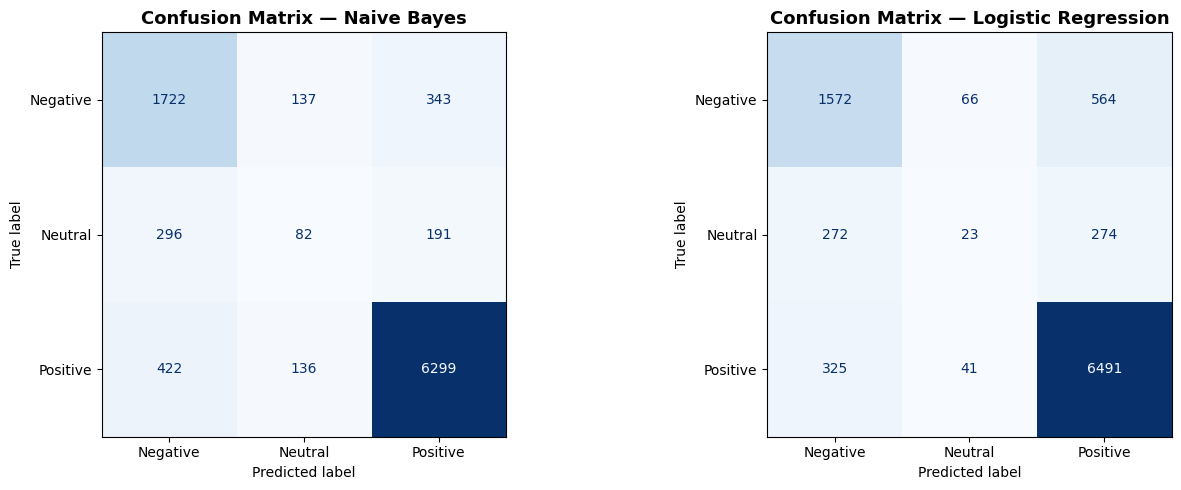

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_nb, y_pred_lr],
    ['Naive Bayes', 'Logistic Regression']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Perbandingan Kedua Model

=== Perbandingan Model ===
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Naive Bayes            0.8416     0.8316  0.8416    0.8356
Logistic Regression    0.8398     0.8070  0.8398    0.8201


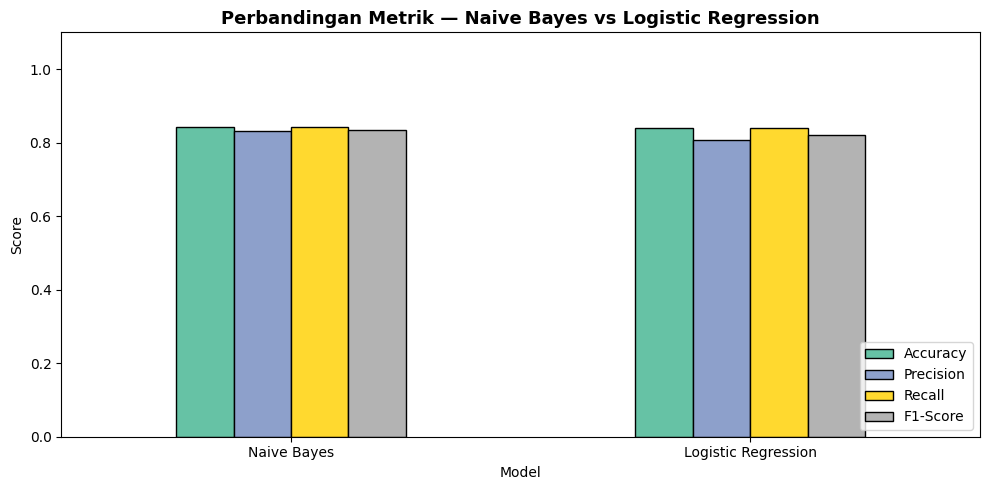

In [21]:
from sklearn.metrics import f1_score, precision_score, recall_score

models = ['Naive Bayes', 'Logistic Regression']
predictions = [y_pred_nb, y_pred_lr]

results = []
for model_name, y_pred in zip(models, predictions):
    results.append({
        'Model'     : model_name,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, average='weighted'),
        'Recall'    : recall_score(y_test, y_pred, average='weighted'),
        'F1-Score'  : f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results).set_index('Model')
print("=== Perbandingan Model ===")
print(results_df.round(4))

# Visualisasi perbandingan
results_df.plot(kind='bar', figsize=(10, 5), edgecolor='black', colormap='Set2')
plt.title('Perbandingan Metrik — Naive Bayes vs Logistic Regression',
          fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

Coba Prediksi Manual

In [22]:
def predict_sentiment(text, model, vectorizer, label_encoder):
    # Bersihkan teks input
    clean = re.sub(r'[^a-zA-Z\s]', ' ', text).lower().strip()
    vec = vectorizer.transform([clean])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]

    print(f"Teks     : {text}")
    print(f"Prediksi : {label_encoder.inverse_transform([pred])[0]}")
    print("Probabilitas per kelas:")
    for cls, prob in zip(label_encoder.classes_, proba):
        print(f"  {cls}: {prob:.4f}")
    print()

# Contoh uji coba
contoh = [
    "aplikasi bca sangat bagus dan mudah digunakan",
    "error terus tidak bisa login sangat mengecewakan",
    "lumayan oke lah biasa saja"
]

print("=== Naive Bayes ===")
for teks in contoh:
    predict_sentiment(teks, nb_model, cv, le)

print("=== Logistic Regression ===")
for teks in contoh:
    predict_sentiment(teks, lr_model, cv, le)

=== Naive Bayes ===
Teks     : aplikasi bca sangat bagus dan mudah digunakan
Prediksi : Positive
Probabilitas per kelas:
  Negative: 0.0013
  Neutral: 0.0004
  Positive: 0.9983

Teks     : error terus tidak bisa login sangat mengecewakan
Prediksi : Negative
Probabilitas per kelas:
  Negative: 0.9086
  Neutral: 0.0751
  Positive: 0.0164

Teks     : lumayan oke lah biasa saja
Prediksi : Positive
Probabilitas per kelas:
  Negative: 0.0104
  Neutral: 0.1342
  Positive: 0.8554

=== Logistic Regression ===
Teks     : aplikasi bca sangat bagus dan mudah digunakan
Prediksi : Positive
Probabilitas per kelas:
  Negative: 0.1148
  Neutral: 0.0036
  Positive: 0.8817

Teks     : error terus tidak bisa login sangat mengecewakan
Prediksi : Negative
Probabilitas per kelas:
  Negative: 0.9524
  Neutral: 0.0285
  Positive: 0.0191

Teks     : lumayan oke lah biasa saja
Prediksi : Positive
Probabilitas per kelas:
  Negative: 0.0295
  Neutral: 0.3017
  Positive: 0.6689



* The news mentioned here is fake.
* Audience do not encourage fake news.
* Fake news is false or misleading"
